# 03 - Transformation, Feature Engineering & Pipeline

**Phase 2 — Membre 3**

Ce notebook fait suite à la partie nettoyage (`03_preprocessing.ipynb` — Membre 2).  
Il couvre les tâches 3.1 à 3.6 :

| Tâche | Contenu |
|-------|---------|
| 3.1 | Encodage des variables catégorielles |
| 3.2 | Normalisation des variables numériques |
| 3.3 | Feature Engineering (3 nouvelles variables) |
| 3.4 | Construction du pipeline scikit-learn |
| 3.5 | Séparation train / validation / test |
| 3.6 | Préparation des stratégies de déséquilibre |

**Dataset :** FAERS Drug Hospitalization Dataset  
**Cible :** `seriousnesshospitalization` (0 = pas d'hospitalisation, 1 = hospitalisation)

## 0. Imports et chargement

In [45]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler,
    OneHotEncoder, OrdinalEncoder
)
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.model_selection import train_test_split

sns.set_theme(style='whitegrid')

# Chemins
CLEAN_PATH  = Path('../data/dataset_cleaned.csv')
PROCESSED   = Path('../data/processed')
MODELS_DIR  = Path('../models')
PROCESSED.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Chargement
df = pd.read_csv(CLEAN_PATH, dtype={'route_of_admin': 'string'})
df['route_of_admin'] = df['route_of_admin'].apply(
    lambda x: str(int(float(x))).zfill(3) if pd.notna(x) else pd.NA
)

print(f'Dataset chargé : {df.shape[0]:,} lignes x {df.shape[1]} colonnes')
df.head()

Dataset chargé : 7,747 lignes x 12 colonnes


,patient_age,nb_drugs,nb_reactions,worst_reaction_outcome,nb_suspect_drugs,patient_sex,reporter_qualification,route_of_admin,country,has_black_box_warning,is_concomitant_present,seriousnesshospitalization
0,26.0,1,2,6.0,1,1.0,3.0,041,US,0,0,0
1,77.0,1,4,6.0,1,2.0,5.0,042,US,0,0,0
2,60.0,1,2,6.0,1,2.0,5.0,048,US,0,0,0
3,60.0,1,1,6.0,1,1.0,5.0,048,US,0,0,0
4,60.0,9,1,6.0,9,2.0,1.0,048,US,1,0,0


### Définition des groupes de colonnes

In [46]:
TARGET = 'seriousnesshospitalization'

# Variables numériques continues
numerical_cols = ['patient_age', 'nb_drugs', 'nb_reactions', 'nb_suspect_drugs']

# Variable ordinale (ordre naturel de gravité)
ordinal_cols  = ['worst_reaction_outcome']
ordinal_order = [[1.0, 2.0, 3.0, 4.0, 5.0, 6.0]]  # 1=recovered ... 6=unknown

# Variables nominales (pas d'ordre)
nominal_cols = [
    'patient_sex', 'reporter_qualification',
    'has_black_box_warning', 'is_concomitant_present',
    'route_of_admin', 'country'
]

# ── Réduction de cardinalité AVANT feature engineering ──────────────────────
# route_of_admin : 30 modalités → dépasse la limite OHE recommandée (< 15)
# On conserve les 10 codes FDA les plus fréquents, le reste → 'other'
top_routes = df['route_of_admin'].value_counts().nlargest(10).index
df['route_of_admin'] = df['route_of_admin'].where(
    df['route_of_admin'].isin(top_routes), other='other'
)
print(f'route_of_admin : {df["route_of_admin"].nunique()} modalités après regroupement (top 10 + other)')

# country : 75 modalités → explosion dimensionnelle avec OHE
# On conserve les 10 pays les plus fréquents, le reste → 'other'
top_countries = df['country'].value_counts().nlargest(10).index
df['country'] = df['country'].where(
    df['country'].isin(top_countries), other='other'
)
print(f'country        : {df["country"].nunique()} modalités après regroupement (top 10 + other)')
print()
print('Numériques :', numerical_cols)
print('Ordinales  :', ordinal_cols)
print('Nominales  :', nominal_cols)
print('Cible      :', TARGET)


route_of_admin : 11 modalités après regroupement (top 10 + other)
country        : 11 modalités après regroupement (top 10 + other)

Numériques : ['patient_age', 'nb_drugs', 'nb_reactions', 'nb_suspect_drugs']
Ordinales  : ['worst_reaction_outcome']
Nominales  : ['patient_sex', 'reporter_qualification', 'has_black_box_warning', 'is_concomitant_present', 'route_of_admin', 'country']
Cible      : seriousnesshospitalization


---
## Tâche 3.1 — Encodage des variables catégorielles

### Justification des choix d'encodage

| Variable | Modalités (brut) | Modalités (après regroupement) | Encodage retenu | Justification |
|----------|-----------------|-------------------------------|-----------------|---------------|
| `patient_sex` | 3 | 3 | **OneHot** | Pas d'ordre naturel entre les sexes |
| `reporter_qualification` | 5 | 5 | **OneHot** | Catégories sans hiérarchie métier claire |
| `has_black_box_warning` | 2 | 2 | **OneHot** | Flag binaire nominal |
| `is_concomitant_present` | 2 | 2 | **OneHot** | Flag binaire nominal |
| `route_of_admin` | **30** | **11** (top 10 + other) | **OneHot** | Cardinalité réduite < 15 ; voies non ordonnées |
| `country` | **75** | **11** (top 10 + other) | **OneHot** | Cardinalité réduite < 15 ; pays sans hiérarchie |
| `worst_reaction_outcome` | 6 | 6 | **Ordinal** | Ordre de gravité : 1=recovered → 5=fatal → 6=unknown |

> **Règle appliquée :** OneHotEncoder pour toutes les variables nominales (< 15 modalités après regroupement).  
> `route_of_admin` (30 modalités) et `country` (75 modalités) ont été regroupés : top 10 modalités conservées, reste → `'other'`.  
> OrdinalEncoder uniquement pour `worst_reaction_outcome` qui possède un ordre naturel de gravité.


In [47]:
# Vérification des cardinalités après regroupement
cat_vars = ordinal_cols + nominal_cols
encodage = ['OrdinalEncoder'] + ['OneHotEncoder'] * len(nominal_cols)
justifs  = [
    'Ordre gravité : 1=recovered → 5=fatal → 6=unknown',
    'Pas d\'ordre naturel M/F/inconnu',
    'Catégories sans hiérarchie métier',
    'Flag binaire nominal',
    'Flag binaire nominal',
    'Top 10 codes FDA + other (cardinalité réduite < 15)',
    'Top 10 pays + other (cardinalité réduite < 15)',
]
cardinality = pd.DataFrame({
    'Variable'      : cat_vars,
    'Modalités'     : [df[c].nunique() for c in cat_vars],
    'Encodage'      : encodage,
    'Justification' : justifs,
})
cardinality


,Variable,Modalités,Encodage,Justification
0,worst_reaction_outcome,6,OrdinalEncoder,Ordre gravité : 1=recovered → 5=fatal → 6=unknown
1,patient_sex,3,OneHotEncoder,Pas d'ordre naturel M/F/inconnu
2,reporter_qualification,5,OneHotEncoder,Catégories sans hiérarchie métier
3,has_black_box_warning,2,OneHotEncoder,Flag binaire nominal
4,is_concomitant_present,2,OneHotEncoder,Flag binaire nominal
5,route_of_admin,11,OneHotEncoder,Top 10 codes FDA + other (cardinalité réduite ...
6,country,11,OneHotEncoder,Top 10 pays + other (cardinalité réduite < 15)


---
## Tâche 3.2 — Normalisation des variables numériques

### Scaler retenu : **RobustScaler**

| Scaler | Formule | Sensibilité aux outliers | Cas d'usage |
|--------|---------|--------------------------|-------------|
| StandardScaler | `(x - μ) / σ` | **Élevée** | Données gaussiennes sans outliers |
| MinMaxScaler | `(x - min) / (max - min)` | **Très élevée** | Données bornées, distributions connues |
| **RobustScaler** | `(x - médiane) / IQR` | **Faible** ✓ | **Données avec outliers** |

**Justification :** En Phase 2, l'analyse IQR a révélé des outliers significatifs sur les 4 variables numériques :
- `patient_age` : 536 outliers IQR
- `nb_drugs` : 398 outliers IQR  
- `nb_reactions` : 399 outliers IQR
- `nb_suspect_drugs` : 711 outliers IQR

Ces valeurs ont été **conservées** (signal clinique), donc le RobustScaler est le seul choix cohérent.

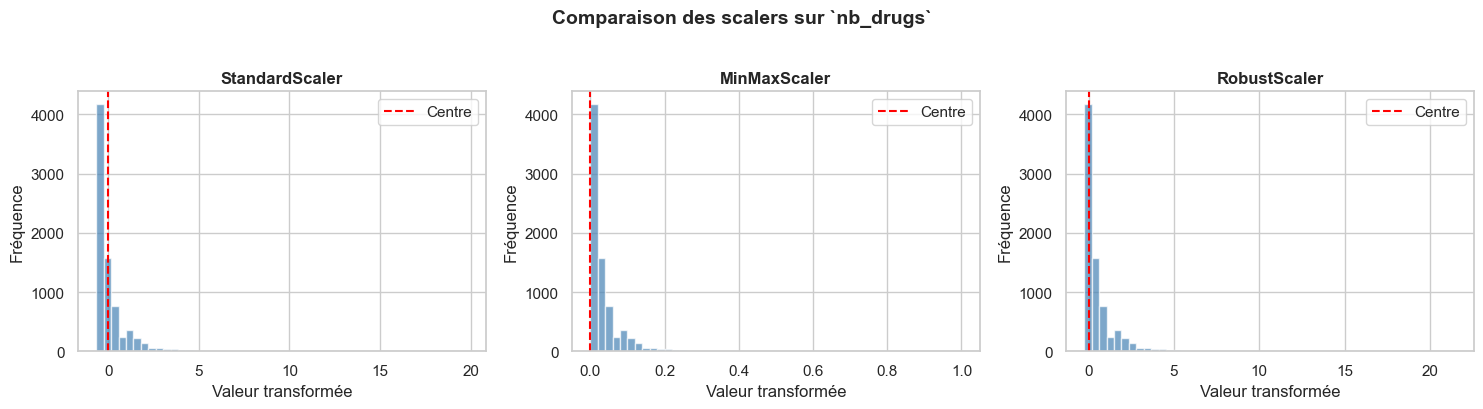

RobustScaler retenu : insensible aux outliers cliniques conservés.


In [48]:
# Illustration de l'impact des outliers sur les scalers
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

col = 'nb_drugs'
data = df[col].values.reshape(-1, 1)

scalers = [
    ('StandardScaler', StandardScaler()),
    ('MinMaxScaler',   MinMaxScaler()),
    ('RobustScaler',   RobustScaler()),
]

for ax, (name, scaler) in zip(axes, scalers):
    scaled = scaler.fit_transform(data).flatten()
    ax.hist(scaled, bins=50, color='steelblue', alpha=0.7, edgecolor='white')
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Valeur transformée')
    ax.set_ylabel('Fréquence')
    ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Centre')
    ax.legend()

plt.suptitle(f"Comparaison des scalers sur `{col}`", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('RobustScaler retenu : insensible aux outliers cliniques conservés.')

---
## Tâche 3.3 ⭐ — Feature Engineering

Création de **3 nouvelles variables** justifiées métier.

### Feature 1 : `ratio_suspect_drugs` (Ratio)

**Formule :** `nb_suspect_drugs / nb_drugs`

**Justification métier :** Dans FAERS, un rapport suspect/total élevé indique que presque tous les médicaments pris par le patient sont soupçonnés d'avoir provoqué la réaction adverse. Ce ratio est un indicateur fort de causalité médicamenteuse et peut être prédictif d'une hospitalisation.

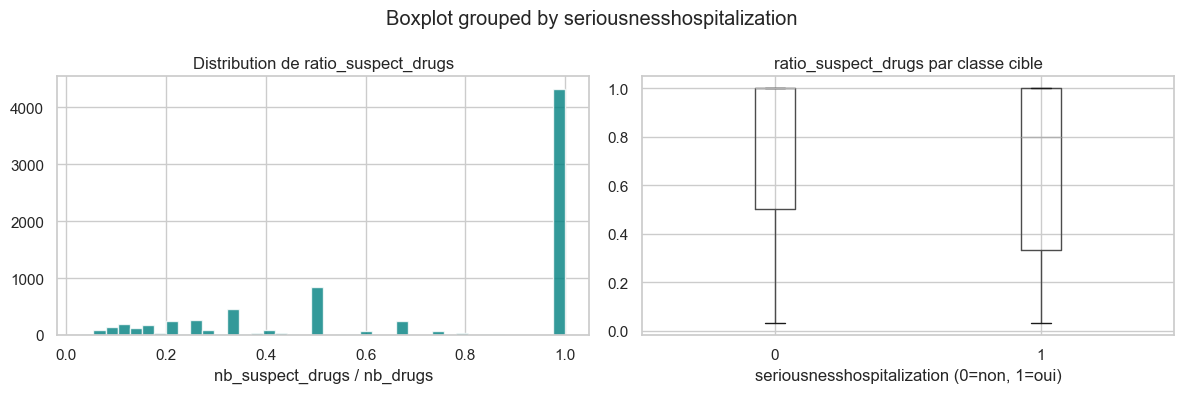

Statistiques par classe :
                             count   mean    std    min    25%  50%  75%  max
seriousnesshospitalization                                                   
0                           5900.0  0.737  0.333  0.032  0.500  1.0  1.0  1.0
1                           1847.0  0.667  0.355  0.030  0.333  0.8  1.0  1.0


In [49]:
df['ratio_suspect_drugs'] = df['nb_suspect_drugs'] / df['nb_drugs'].replace(0, np.nan)
df['ratio_suspect_drugs'] = df['ratio_suspect_drugs'].fillna(0.0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['ratio_suspect_drugs'].hist(bins=40, ax=axes[0], color='teal', alpha=0.8, edgecolor='white')
axes[0].set_title('Distribution de ratio_suspect_drugs')
axes[0].set_xlabel('nb_suspect_drugs / nb_drugs')

df.boxplot(column='ratio_suspect_drugs', by=TARGET, ax=axes[1])
axes[1].set_title('ratio_suspect_drugs par classe cible')
axes[1].set_xlabel('seriousnesshospitalization (0=non, 1=oui)')

plt.tight_layout()
plt.show()

print('Statistiques par classe :')
print(df.groupby(TARGET)['ratio_suspect_drugs'].describe().round(3))

### Feature 2 : `age_group` (Binning)

**Formule :** Découpage de `patient_age` en 5 tranches

| Tranche | Âge | Justification |
|---------|-----|---------------|
| nourrisson | 0–2 ans | Immaturité hépatique/rénale → risque élevé |
| enfant | 2–18 ans | Pharmacocinétique différente de l'adulte |
| adulte | 18–65 ans | Population de référence |
| senior | 65–75 ans | Poly-médication fréquente, fragilité |
| tres_age | 75–120 ans | Comorbidités multiples, hospitalisations fréquentes |

**Justification métier :** Les études de pharmacovigilance montrent que les nourrissons et les patients très âgés ont des profils pharmacocinétiques particuliers et une vulnérabilité accrue aux effets indésirables graves.

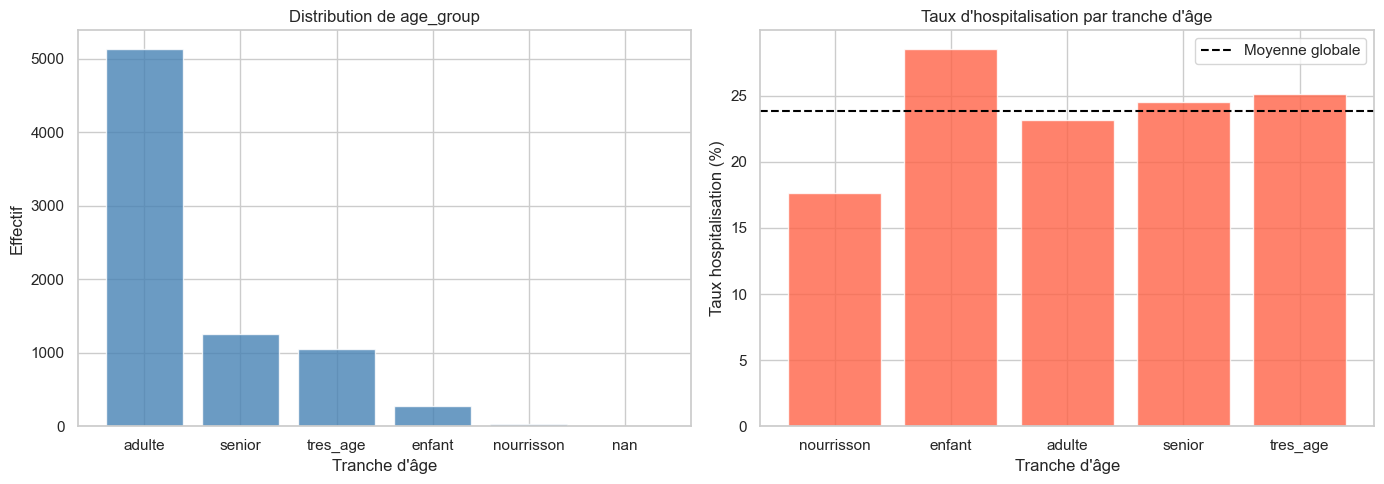

In [50]:
bins   = [0, 2, 18, 65, 75, 120]
labels = ['nourrisson', 'enfant', 'adulte', 'senior', 'tres_age']
df['age_group'] = pd.cut(
    df['patient_age'], bins=bins, labels=labels, right=True
).astype(str)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = labels
counts = df['age_group'].value_counts()
axes[0].bar(counts.index, counts.values, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].set_title('Distribution de age_group')
axes[0].set_xlabel('Tranche d\'âge')
axes[0].set_ylabel('Effectif')

hosp_rate = df.groupby('age_group')[TARGET].mean().reindex(labels)
axes[1].bar(hosp_rate.index, hosp_rate.values * 100, color='tomato', alpha=0.8, edgecolor='white')
axes[1].set_title('Taux d\'hospitalisation par tranche d\'âge')
axes[1].set_xlabel('Tranche d\'âge')
axes[1].set_ylabel('Taux hospitalisation (%)')
axes[1].axhline(df[TARGET].mean() * 100, color='black', linestyle='--', label='Moyenne globale')
axes[1].legend()

plt.tight_layout()
plt.show()

### Feature 3 : `severity_polypharmacy` (Interaction)

**Formule :** `(7 - worst_reaction_outcome) × nb_drugs`

**Justification métier :** 
- `7 - worst_reaction_outcome` inverse l'échelle FDA pour que les valeurs élevées = gravité élevée (1=fatal après inversion=6, 6=unknown=1)
- Le produit capture l'**interaction** entre la sévérité de la réaction et le nombre de médicaments pris
- Une réaction grave combinée à de nombreux médicaments représente un profil à haut risque d'hospitalisation

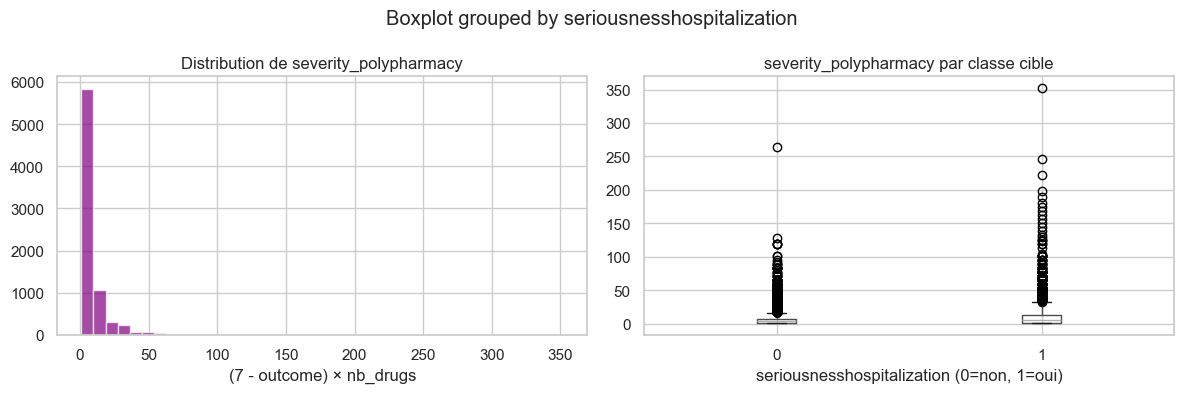

Statistiques par classe :
                             count    mean     std  min  25%  50%   75%    max
seriousnesshospitalization                                                    
0                           5900.0   7.224  11.242  1.0  2.0  4.0   8.0  264.0
1                           1847.0  13.680  23.969  1.0  2.0  6.0  14.0  352.0


In [51]:
df['severity_polypharmacy'] = (7 - df['worst_reaction_outcome']) * df['nb_drugs']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['severity_polypharmacy'].hist(bins=40, ax=axes[0], color='purple', alpha=0.7, edgecolor='white')
axes[0].set_title('Distribution de severity_polypharmacy')
axes[0].set_xlabel('(7 - outcome) × nb_drugs')

df.boxplot(column='severity_polypharmacy', by=TARGET, ax=axes[1])
axes[1].set_title('severity_polypharmacy par classe cible')
axes[1].set_xlabel('seriousnesshospitalization (0=non, 1=oui)')

plt.tight_layout()
plt.show()

print('Statistiques par classe :')
print(df.groupby(TARGET)['severity_polypharmacy'].describe().round(3))

### Récapitulatif des features engineered

In [52]:
fe_summary = pd.DataFrame([
    {
        'Feature': 'ratio_suspect_drugs',
        'Type': 'Ratio',
        'Formule': 'nb_suspect_drugs / nb_drugs',
        'Justification metier': 'Ratio élevé = presque tous médicaments suspects = signal fort de causalité adverse'
    },
    {
        'Feature': 'age_group',
        'Type': 'Binning',
        'Formule': 'pd.cut(patient_age, [0,2,18,65,75,120])',
        'Justification metier': 'Nourrissons & très âgés = profils pharmakocinétiques vulnérables'
    },
    {
        'Feature': 'severity_polypharmacy',
        'Type': 'Interaction',
        'Formule': '(7 - worst_reaction_outcome) × nb_drugs',
        'Justification metier': 'Réaction grave + polymédication = profil haut risque hospitalisation'
    },
])

fe_summary

,Feature,Type,Formule,Justification metier
0,ratio_suspect_drugs,Ratio,nb_suspect_drugs / nb_drugs,Ratio élevé = presque tous médicaments suspect...
1,age_group,Binning,"pd.cut(patient_age, [0,2,18,65,75,120])",Nourrissons & très âgés = profils pharmakociné...
2,severity_polypharmacy,Interaction,(7 - worst_reaction_outcome) × nb_drugs,Réaction grave + polymédication = profil haut ...


---
## Tâche 3.4 — Construction du Pipeline scikit-learn

In [53]:
# Mise à jour des listes de colonnes après feature engineering
numerical_cols_fe = numerical_cols + ['ratio_suspect_drugs', 'severity_polypharmacy']
nominal_cols_fe   = nominal_cols + ['age_group']

print(f'Variables numériques ({len(numerical_cols_fe)}) :', numerical_cols_fe)
print(f'Variables ordinales  ({len(ordinal_cols)}) :', ordinal_cols)
print(f'Variables nominales  ({len(nominal_cols_fe)}) :', nominal_cols_fe)

Variables numériques (6) : ['patient_age', 'nb_drugs', 'nb_reactions', 'nb_suspect_drugs', 'ratio_suspect_drugs', 'severity_polypharmacy']
Variables ordinales  (1) : ['worst_reaction_outcome']
Variables nominales  (7) : ['patient_sex', 'reporter_qualification', 'has_black_box_warning', 'is_concomitant_present', 'route_of_admin', 'country', 'age_group']


In [54]:
# Sous-pipeline numérique
# KNNImputer pour capturer les corrélations entre variables numériques
# RobustScaler pour gérer les outliers préservés
numeric_pipeline = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler',  RobustScaler())
])

# Sous-pipeline ordinal
# SimpleImputer(mode) puis OrdinalEncoder avec l'ordre de gravité FDA
ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        categories=ordinal_order,
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])

# Sous-pipeline catégoriel nominal
# SimpleImputer(mode) puis OneHotEncoder
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Pipeline global avec ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline,     numerical_cols_fe),
    ('ord', ordinal_pipeline,     ordinal_cols),
    ('cat', categorical_pipeline, nominal_cols_fe),
])

print('Pipeline construit avec succès !')
print()
print('Structure :')
print('  ColumnTransformer')
print('    ├── num : KNNImputer(k=5) → RobustScaler')
print('    ├── ord : SimpleImputer(mode) → OrdinalEncoder([1,2,3,4,5,6])')
print('    └── cat : SimpleImputer(mode) → OneHotEncoder(handle_unknown=ignore)')

Pipeline construit avec succès !

Structure :
  ColumnTransformer
    ├── num : KNNImputer(k=5) → RobustScaler
    ├── ord : SimpleImputer(mode) → OrdinalEncoder([1,2,3,4,5,6])
    └── cat : SimpleImputer(mode) → OneHotEncoder(handle_unknown=ignore)


In [55]:
# Sérialisation du pipeline (sera fit après le split en tâche 3.5)
# joblib.dump(preprocessor, MODELS_DIR / 'preprocessor.joblib')
# → exécuté après fit_transform sur X_train en tâche 3.5

---
## Tâche 3.5 — Séparation train / validation / test

**Stratégie :** Split stratifié pour préserver le ratio de déséquilibre dans chaque partition.

| Split | Proportion | Rôle |
|-------|-----------|------|
| Train | 70% | Entraînement des modèles |
| Validation | 15% | Sélection du modèle / hyperparamètres |
| Test | 15% | Évaluation finale (touché une seule fois) |

In [56]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

print(f'Distribution cible globale :')
print(y.value_counts())
print(f'  Classe 0 : {(y==0).mean()*100:.2f}%')
print(f'  Classe 1 : {(y==1).mean()*100:.2f}%')

Distribution cible globale :
seriousnesshospitalization
0    5900
1    1847
Name: count, dtype: int64
  Classe 0 : 76.16%
  Classe 1 : 23.84%


In [57]:
# Split stratifié 70 / 15 / 15
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print('Tailles des splits :')
print(f'  Train      : {len(X_train):,} lignes ({len(X_train)/len(X)*100:.1f}%)')
print(f'  Validation : {len(X_val):,} lignes  ({len(X_val)/len(X)*100:.1f}%)')
print(f'  Test       : {len(X_test):,} lignes  ({len(X_test)/len(X)*100:.1f}%)')

Tailles des splits :
  Train      : 5,422 lignes (70.0%)
  Validation : 1,162 lignes  (15.0%)
  Test       : 1,163 lignes  (15.0%)


In [58]:
# Vérification de la préservation du ratio de déséquilibre
splits = {
    'Global': y,
    'Train':  y_train,
    'Validation': y_val,
    'Test': y_test
}

ratio_df = pd.DataFrame([
    {
        'Split': name,
        'N': len(s),
        'Classe 0 (%)': round((s == 0).mean() * 100, 2),
        'Classe 1 (%)': round((s == 1).mean() * 100, 2),
    }
    for name, s in splits.items()
])

print('Vérification du ratio de déséquilibre par split :')
ratio_df

Vérification du ratio de déséquilibre par split :


,Split,N,Classe 0 (%),Classe 1 (%)
0,Global,7747,76.16,23.84
1,Train,5422,76.15,23.85
2,Validation,1162,76.16,23.84
3,Test,1163,76.18,23.82


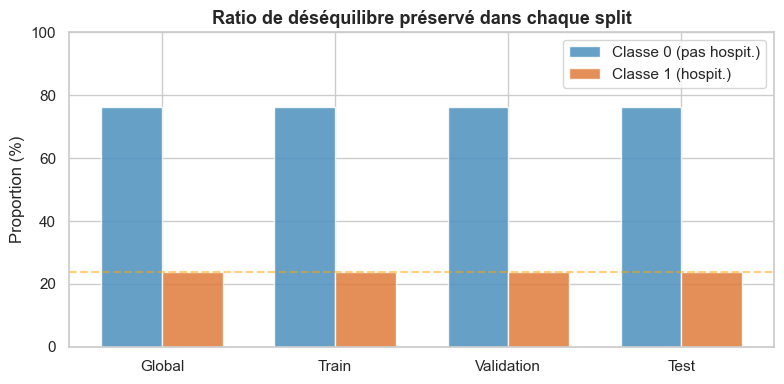

Ratio de desequilibre preserve dans les 3 splits. OK


In [59]:
# Visualisation
fig, ax = plt.subplots(figsize=(8, 4))

x    = np.arange(len(ratio_df))
w    = 0.35
bars0 = ax.bar(x - w/2, ratio_df['Classe 0 (%)'], w, label='Classe 0 (pas hospit.)', color='#4c8fbe', alpha=0.85)
bars1 = ax.bar(x + w/2, ratio_df['Classe 1 (%)'], w, label='Classe 1 (hospit.)',      color='#e07b39', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(ratio_df['Split'])
ax.set_ylabel('Proportion (%)')
ax.set_title('Ratio de déséquilibre préservé dans chaque split', fontsize=13, fontweight='bold')
ax.legend()
ax.set_ylim(0, 100)
ax.axhline(df[TARGET].mean() * 100, color='orange', linestyle='--', linewidth=1.5, alpha=0.5)

plt.tight_layout()
plt.show()

print('Ratio de desequilibre preserve dans les 3 splits. OK')

In [60]:
# Fit du preprocessor sur X_train UNIQUEMENT (éviter le data leakage)
preprocessor.fit(X_train)

# Sérialisation du pipeline fitté
joblib.dump(preprocessor, MODELS_DIR / 'preprocessor.joblib')
print(f'models/preprocessor.joblib sauvegardé.')

# Sauvegarde des splits CSV (données brutes + features engineered)
train_df = X_train.copy(); train_df[TARGET] = y_train
val_df   = X_val.copy();   val_df[TARGET]   = y_val
test_df  = X_test.copy();  test_df[TARGET]  = y_test

train_df.to_csv(PROCESSED / 'train.csv',      index=False)
val_df.to_csv(  PROCESSED / 'validation.csv', index=False)
test_df.to_csv( PROCESSED / 'test.csv',       index=False)

print(f'data/processed/train.csv       ({len(train_df):,} lignes)')
print(f'data/processed/validation.csv  ({len(val_df):,} lignes)')
print(f'data/processed/test.csv        ({len(test_df):,} lignes)')

models/preprocessor.joblib sauvegardé.
data/processed/train.csv       (5,422 lignes)
data/processed/validation.csv  (1,162 lignes)
data/processed/test.csv        (1,163 lignes)


In [61]:
# Transformation des splits
X_train_t = preprocessor.transform(X_train)
X_val_t   = preprocessor.transform(X_val)
X_test_t  = preprocessor.transform(X_test)

print(f'Dimensions après transformation pipeline :')
print(f'  X_train_t : {X_train_t.shape}')
print(f'  X_val_t   : {X_val_t.shape}')
print(f'  X_test_t  : {X_test_t.shape}')

Dimensions après transformation pipeline :
  X_train_t : (5422, 47)
  X_val_t   : (1162, 47)
  X_test_t  : (1163, 47)


---
## Tâche 3.6 — Préparation des stratégies de déséquilibre

Le déséquilibre de classe (~24% de positifs) sera traité en Phase 3 avec 3 stratégies :

| Stratégie | Méthode | Avantage | Inconvénient |
|-----------|---------|----------|--------------|
| 1 | `class_weight='balanced'` | Rapide, sans données synthétiques | Moins efficace si très déséquilibré |
| 2 | SMOTE (oversampling) | Génère des exemples positifs réalistes | Peut sur-apprendre |
| 3 | RandomUnderSampler | Réduit le bruit de la classe majoritaire | Perte d'information |

> **Important (Phase 3) :** SMOTE et RandomUnderSampler seront intégrés via `imblearn.pipeline.Pipeline`
> (et non `sklearn.pipeline.Pipeline`) pour garantir qu'ils s'appliquent **uniquement sur le fold d'entraînement**
> lors de la validation croisée — évitant ainsi un data leakage.
> En Phase 2, on les applique ici sur `X_train_t` déjà transformé pour visualiser les distributions.


In [62]:
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.under_sampling import RandomUnderSampler
    IMBLEARN_AVAILABLE = True
    print('imbalanced-learn disponible.')
except ImportError:
    IMBLEARN_AVAILABLE = False
    print('imbalanced-learn non installe. Executer : pip install imbalanced-learn')

print(f'\nDistribution originale X_train :')
print(y_train.value_counts())

imbalanced-learn non installe. Executer : pip install imbalanced-learn

Distribution originale X_train :
seriousnesshospitalization
0    4129
1    1293
Name: count, dtype: int64


In [63]:
# ============================================================
# Stratégie 1 : class_weight='balanced'
# ============================================================
# Sera passé directement au modèle en Phase 3, pas de rééchantillonnage
# Exemple d'utilisation :

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Ces modèles seront instanciés en Phase 3 :
# lr_balanced  = LogisticRegression(class_weight='balanced', max_iter=1000)
# svc_balanced = SVC(class_weight='balanced', probability=True)

print('Strategie 1 : class_weight="balanced"')
print('  Le classifieur ajuste automatiquement les poids de chaque classe.')
print('  Poids = n_samples / (n_classes * n_samples_per_class)')
print()

n0, n1 = (y_train == 0).sum(), (y_train == 1).sum()
n      = len(y_train)
w0     = n / (2 * n0)
w1     = n / (2 * n1)
print(f'  Poids classe 0 : {w0:.3f}')
print(f'  Poids classe 1 : {w1:.3f}')

Strategie 1 : class_weight="balanced"
  Le classifieur ajuste automatiquement les poids de chaque classe.
  Poids = n_samples / (n_classes * n_samples_per_class)

  Poids classe 0 : 0.657
  Poids classe 1 : 2.097


In [64]:
# ============================================================
# Stratégie 2 : SMOTE
# NOTE Phase 3 : intégrer dans imblearn.pipeline.Pipeline
#   from imblearn.pipeline import Pipeline as ImbPipeline
#   pipe = ImbPipeline([('pre', preprocessor), ('smote', SMOTE()), ('clf', model)])
# ============================================================
if IMBLEARN_AVAILABLE:
    smote = SMOTE(random_state=42)
    X_train_sm, y_train_sm = smote.fit_resample(X_train_t, y_train)

    print('Strategie 2 : SMOTE (Synthetic Minority Oversampling Technique)')
    print(f'  Avant : {X_train_t.shape[0]:,} échantillons → Apres : {X_train_sm.shape[0]:,}')
    print(f'  Distribution : {pd.Series(y_train_sm).value_counts().to_dict()}')
    print()
    print('  ⚠ En Phase 3 : utiliser imblearn.pipeline.Pipeline pour éviter le data leakage en CV.')
else:
    print('SMOTE non disponible. Installer imbalanced-learn.')
    print()
    print('Code prêt (Phase 3 avec imblearn.pipeline) :')
    print('''    from imblearn.pipeline import Pipeline as ImbPipeline
    pipe = ImbPipeline([
        ("pre",   preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("clf",   model)
    ])''')


SMOTE non disponible. Installer imbalanced-learn.

Code prêt (Phase 3 avec imblearn.pipeline) :
    from imblearn.pipeline import Pipeline as ImbPipeline
    pipe = ImbPipeline([
        ("pre",   preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("clf",   model)
    ])


In [65]:
# ============================================================
# Stratégie 3 : RandomUnderSampler
# NOTE Phase 3 : intégrer dans imblearn.pipeline.Pipeline
#   from imblearn.pipeline import Pipeline as ImbPipeline
#   pipe = ImbPipeline([('pre', preprocessor), ('rus', RandomUnderSampler()), ('clf', model)])
# ============================================================
if IMBLEARN_AVAILABLE:
    rus = RandomUnderSampler(random_state=42)
    X_train_rus, y_train_rus = rus.fit_resample(X_train_t, y_train)

    print('Strategie 3 : RandomUnderSampler')
    print(f'  Avant : {X_train_t.shape[0]:,} échantillons → Apres : {X_train_rus.shape[0]:,}')
    print(f'  Distribution : {pd.Series(y_train_rus).value_counts().to_dict()}')
    print()
    print('  ⚠ En Phase 3 : utiliser imblearn.pipeline.Pipeline pour éviter le data leakage en CV.')
else:
    print('RandomUnderSampler non disponible. Installer imbalanced-learn.')
    print()
    print('Code prêt (Phase 3 avec imblearn.pipeline) :')
    print('''    from imblearn.pipeline import Pipeline as ImbPipeline
    pipe = ImbPipeline([
        ("pre", preprocessor),
        ("rus", RandomUnderSampler(random_state=42)),
        ("clf", model)
    ])''')


RandomUnderSampler non disponible. Installer imbalanced-learn.

Code prêt (Phase 3 avec imblearn.pipeline) :
    from imblearn.pipeline import Pipeline as ImbPipeline
    pipe = ImbPipeline([
        ("pre", preprocessor),
        ("rus", RandomUnderSampler(random_state=42)),
        ("clf", model)
    ])


In [66]:
if IMBLEARN_AVAILABLE:
    # Visualisation comparative des 3 stratégies
    strategies = {
        'Original': y_train,
        'class_weight': y_train,  # même distribution, le poids est interne au modèle
        'SMOTE': y_train_sm,
        'UnderSampling': y_train_rus
    }

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    colors = ['#4c8fbe', '#27ae60', '#e67e22', '#e74c3c']

    for ax, (name, y_s), color in zip(axes, strategies.items(), colors):
        counts = pd.Series(y_s).value_counts().sort_index()
        ax.bar(['Classe 0', 'Classe 1'], counts.values, color=color, alpha=0.8, edgecolor='white')
        ax.set_title(name, fontweight='bold')
        ax.set_ylabel('Effectif')
        for i, v in enumerate(counts.values):
            ax.text(i, v + 20, str(v), ha='center', fontsize=9)

    plt.suptitle('Comparaison des stratégies de déséquilibre', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

---
## Récapitulatif des livrables Membre 3

| Livrable | Statut | Description |
|----------|--------|-------------|
| `notebooks/03_transformation_pipeline.ipynb` | ✅ | Ce notebook |
| `models/preprocessor.joblib` | ✅ | Pipeline scikit-learn fitté sur X_train |
| `data/processed/train.csv` | ✅ | 70% des données (split stratifié) |
| `data/processed/validation.csv` | ✅ | 15% des données |
| `data/processed/test.csv` | ✅ | 15% des données |

### Décisions techniques

| Choix | Décision | Justification |
|-------|----------|---------------|
| Scaler | **RobustScaler** | Outliers cliniques préservés en Phase 2 |
| Encodage nominal | **OneHotEncoder** | Variables sans ordre naturel |
| Encodage ordinal | **OrdinalEncoder** | `worst_reaction_outcome` : ordre de gravité FDA |
| Cardinalité `route_of_admin` | **Top 10 + other** | 30 modalités → réduit à 11 (< 15) |
| Cardinalité `country` | **Top 10 + other** | 75 modalités → réduit à 11 (< 15) |
| Imputation numérique pipeline | **KNNImputer** | Capture les corrélations entre variables |
| Split | **70/15/15 stratifié** | Préserve le ratio déséquilibre dans chaque partition |
| Stratégies déséquilibre (Phase 3) | **imblearn.pipeline.Pipeline** | SMOTE/UnderSampler appliqués uniquement sur train en CV |

### Features engineered

| Feature | Type | Signal métier |
|---------|------|---------------|
| `ratio_suspect_drugs` | Ratio | Causalité médicamenteuse |
| `age_group` | Binning | Vulnérabilité selon l'âge |
| `severity_polypharmacy` | Interaction | Gravité × polymédication |
